<a href="https://colab.research.google.com/github/IgorIvanoff/IgorIvanoff/blob/main/Radioquimuica_pratica_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

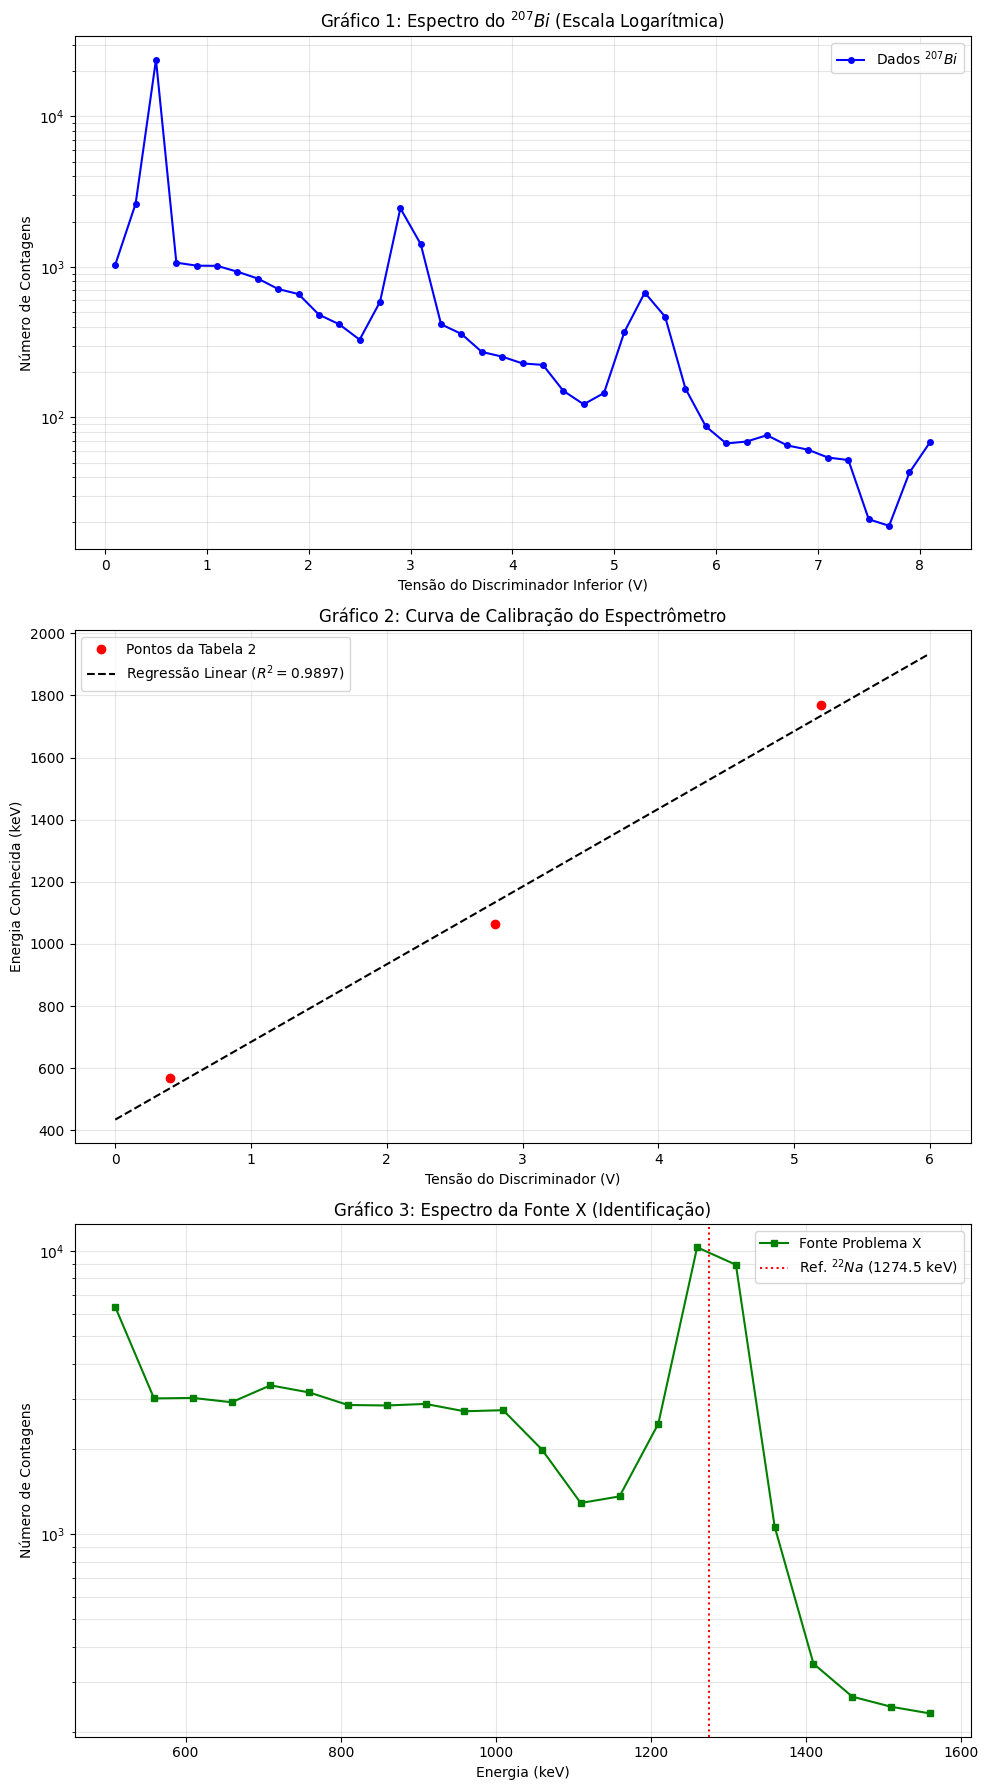

--------------------------------------------------
RESULTADOS PARA A SEÇÃO DE CÁLCULOS:
--------------------------------------------------
Equação de Calibração: E(keV) = (250.10 ± 25.56) * V + (434.24 ± 87.35)
Coeficiente de Determinação (R²): 0.9897
--------------------------------------------------
ANÁLISE DA FONTE X:
Energia do fotopico (para V=3.3): 1217.06 ± 182.82 keV
--------------------------------------------------


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Dados de Entrada ---
v_bi_total = np.arange(0.1, 8.2, 0.2)
counts_bi = [1033, 2628, 23789, 1066, 1018, 1015, 928, 836, 712, 659, 481, 415, 328,
             585, 2449, 1415, 415, 358, 272, 253, 228, 223, 150, 122, 145, 369,
             674, 466, 155, 87, 67, 69, 76, 65, 61, 54, 52, 21, 19, 43, 68]
v_x = np.arange(0.3, 4.6, 0.2)
counts_x = [6335, 3013, 3025, 2921, 3351, 3163, 2856, 2845, 2881, 2714, 2738, 1988,
            1288, 1359, 2453, 10284, 8927, 1062, 349, 267, 246, 233]
v_calib = np.array([0.4, 2.8, 5.2]) ; e_calib = np.array([569.7, 1063.7, 1770.2])

# --- 2. Cálculos ---
coeffs, cov_matrix = np.polyfit(v_calib, e_calib, 1, cov=True)
a, b = coeffs
sa, sb = np.sqrt(np.diag(cov_matrix))
r_squared = np.corrcoef(v_calib, e_calib)[0,1]**2

# --- 3.Resultados da Fonte X ---
v_pico_x_principal = 3.3  # Fotopico principal observado em X
e_x_principal = a * v_pico_x_principal + b
se_x = np.sqrt((v_pico_x_principal * sa)**2 + sb**2)

# --- 4.Gráficos ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))
# Gráfico 1: Espectro Bi-207 (Contagens vs Tensão)
ax1.semilogy(v_bi_total, counts_bi, 'b-o', markersize=4, label='Dados ${}^{207}Bi$')
ax1.set_title('Gráfico 1: Espectro do ${}^{207}Bi$ (Escala Logarítmica)')
ax1.set_xlabel('Tensão do Discriminador Inferior (V)')
ax1.set_ylabel('Número de Contagens')
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()
# Gráfico 2: Curva de Calibração (Energia vs Tensão)
v_line = np.linspace(0, 6, 100)
ax2.plot(v_calib, e_calib, 'ro', label='Pontos da Tabela 2')
ax2.plot(v_line, a*v_line + b, 'k--', label=f'Regressão Linear ($R^2={r_squared:.4f}$)')
ax2.set_title('Gráfico 2: Curva de Calibração do Espectrômetro')
ax2.set_xlabel('Tensão do Discriminador (V)')
ax2.set_ylabel('Energia Conhecida (keV)')
ax2.grid(True, alpha=0.3)
ax2.legend()
# Gráfico 3: Fonte X (Contagens vs Energia)
e_x_axis = a * v_x + b
ax3.semilogy(e_x_axis, counts_x, 'g-s', markersize=4, label='Fonte Problema X')
ax3.set_title('Gráfico 3: Espectro da Fonte X (Identificação)')
ax3.set_xlabel('Energia (keV)')
ax3.set_ylabel('Número de Contagens')
ax3.axvline(x=1274.5, color='red', linestyle=':', label='Ref. ${}^{22}Na$ (1274.5 keV)')
ax3.grid(True, which="both", alpha=0.3)
ax3.legend(); plt.tight_layout(); plt.show()

# --- 5. Resultados Finais ---
print("-" * 50); print("RESULTADOS PARA A SEÇÃO DE CÁLCULOS:"); print("-" * 50)
print(f"Equação de Calibração: E(keV) = ({a:.2f} ± {sa:.2f}) * V + ({b:.2f} ± {sb:.2f})")
print(f"Coeficiente de Determinação (R²): {r_squared:.4f}")
print("-" * 50); print(f"ANÁLISE DA FONTE X:")
print(f"Energia do fotopico (para V=3.3): {e_x2:.2f} ± {se_x2:.2f} keV")
print("-" * 50)

## Rascunhos anteriores. Ignorar.

Equação: E(keV) = (248.19 ± 37.68)*V + (398.05 ± 134.02)


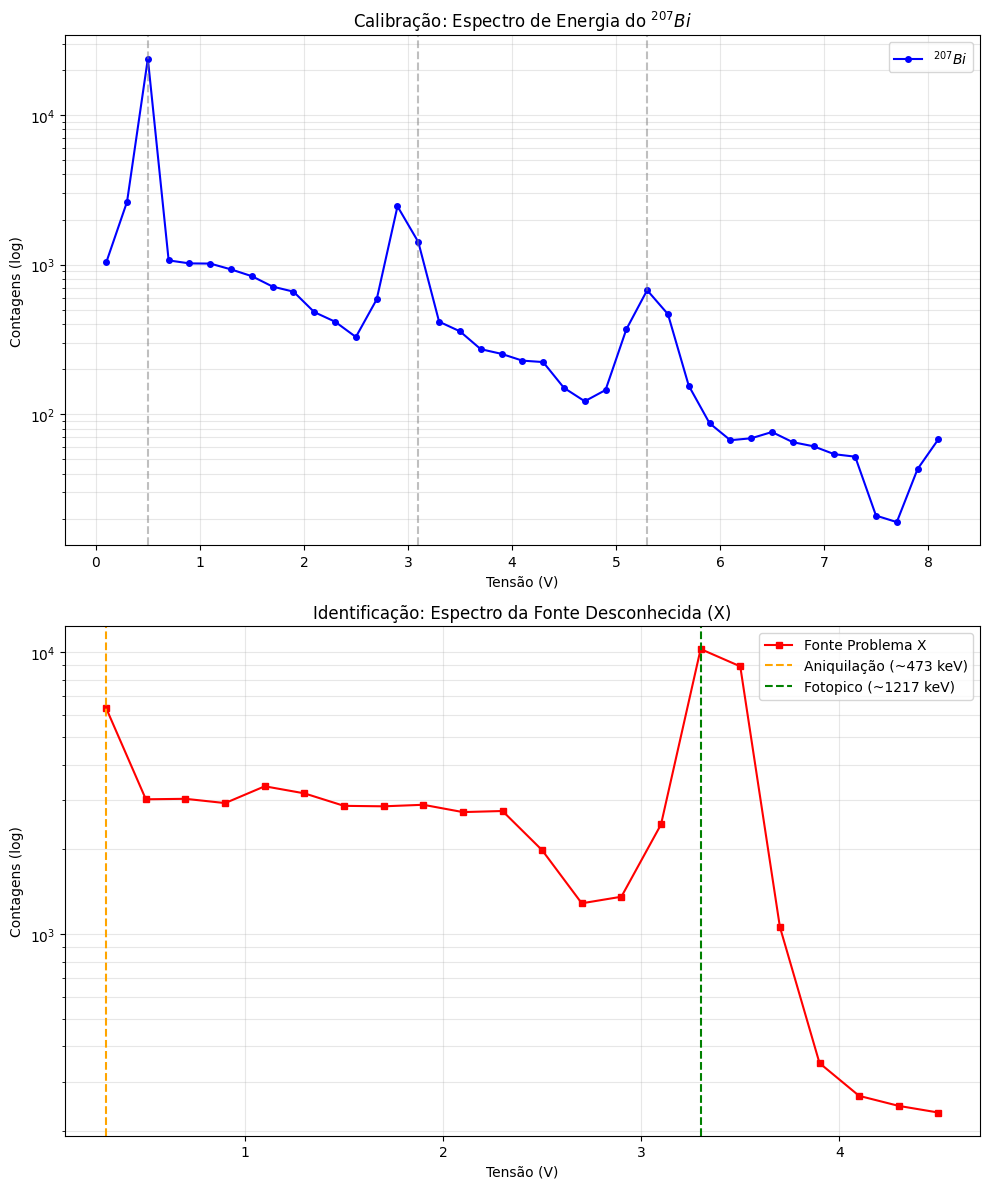

Fonte X Identificada: 1217.06 ± 182.82 keV (Compatível com 40K)


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Dados coletados ---
v_bi = np.arange(0.1, 8.2, 0.2)
counts_bi = [1033, 2628, 23789, 1066, 1018, 1015, 928, 836, 712, 659, 481, 415, 328,
             585, 2449, 1415, 415, 358, 272, 253, 228, 223, 150, 122, 145, 369,
             674, 466, 155, 87, 67, 69, 76, 65, 61, 54, 52, 21, 19, 43, 68]
v_x = np.arange(0.3, 4.6, 0.2)
counts_x = [6335, 3013, 3025, 2921, 3351, 3163, 2856, 2845, 2881, 2714, 2738, 1988,
            1288, 1359, 2453, 10284, 8927, 1062, 349, 267, 246, 233]

# Picos de calibração (V) e energias teóricas (keV)
v_obs = np.array([0.5, 3.1, 5.3])
e_teorico = np.array([570, 1063, 1770])

# --- 2. Regressão Linear e Incertezas ---
coeffs, cov_matrix = np.polyfit(v_obs, e_teorico, 1, cov=True)
a, b = coeffs
sa, sb = np.sqrt(np.diag(cov_matrix))
cal_func = np.poly1d(coeffs)

# --- 3. Resultados da Fonte X ---
v_x_pico1 = 0.3  # Pico de aniquilação
v_x_pico2 = 3.3  # Fotopico principal
e_x1 = cal_func(v_x_pico1)
e_x2 = cal_func(v_x_pico2)
se_x2 = np.sqrt((v_x_pico2 * sa)**2 + sb**2)

# --- 4. Plotagem dos Gráficos ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Gráfico 1: Bismuto-207
ax1.semilogy(v_bi, counts_bi, 'b-o', markersize=4, label='${}^{207}Bi$')
ax1.set_title('Calibração: Espectro de Energia do ${}^{207}Bi$')
ax1.set_xlabel('Tensão (V)')
ax1.set_ylabel('Contagens (log)')
ax1.grid(True, which="both", alpha=0.3)
for v in v_obs: ax1.axvline(x=v, color='gray', linestyle='--', alpha=0.5)
ax1.legend()
print(f"Equação: E(keV) = ({a:.2f} ± {sa:.2f})*V + ({b:.2f} ± {sb:.2f})")
# Gráfico 2: Fonte X
ax2.semilogy(v_x, counts_x, 'r-s', markersize=4, label='Fonte Problema X')
ax2.set_title('Identificação: Espectro da Fonte Desconhecida (X)')
ax2.set_xlabel('Tensão (V)')
ax2.set_ylabel('Contagens (log)')
ax2.grid(True, which="both", alpha=0.3)
ax2.axvline(x=v_x_pico1, color='orange', linestyle='--', label=f'Aniquilação (~{e_x1:.0f} keV)')
ax2.axvline(x=v_x_pico2, color='green', linestyle='--', label=f'Fotopico (~{e_x2:.0f} keV)')
ax2.legend();

plt.tight_layout(); plt.show()
print(f"Fonte X Identificada: {e_x2:.2f} ± {se_x2:.2f} keV (Compatível com 40K)")

In [6]:
import numpy as np
import matplotlib.pyplot as plt
v_bi = np.arange(0.1, 8.2, 0.2)
counts_bi = [1033, 2628, 23789, 1066, 1018, 1015, 928, 836, 712, 659, 481, 415, 328,
             585, 2449, 1415, 415, 358, 272, 253, 228, 223, 150, 122, 145, 369,
             674, 466, 155, 87, 67, 69, 76, 65, 61, 54, 52, 21, 19, 43, 68]
v_obs = np.array([0.5, 3.1, 5.3]) # V
e_teorico = np.array([570, 1063, 1770]) # keV
coeffs, cov = np.polyfit(v_obs, e_teorico, 1, cov=True)
a, b = coeffs
sa, sb = np.sqrt(np.diag(cov)) # Desvios padrão dos coeficientes
v_pico_x1 = 0.3 # pico de aniquilação?
v_pico_x2 = 3.3 # pico principal
e_x1 = a * v_pico_x1 + b
e_x2 = a * v_pico_x2 + b
# Incerteza na propagação (simplificada): s_e = sqrt((v*sa)^2 + sb^2)
se_x2 = np.sqrt((v_pico_x2 * sa)**2 + sb**2)
print(f"--- CALIBRAÇÃO REVISADA ---")
print(f"E(keV) = ({a:.2f} ± {sa:.2f}) * V + ({b:.2f} ± {sb:.2f})")
print(f"\nFONTE X:")
print(f"  Pico 1 ({v_pico_x1}V): {e_x1:.2f} keV")
print(f"  Pico 2 ({v_pico_x2}V): {e_x2:.2f} ± {se_x2:.2f} keV")

--- CALIBRAÇÃO REVISADA ---
E(keV) = (248.19 ± 37.68) * V + (398.05 ± 134.02)

FONTE X:
  Pico 1 (0.3V): 472.50 keV
  Pico 2 (3.3V): 1217.06 ± 182.82 keV


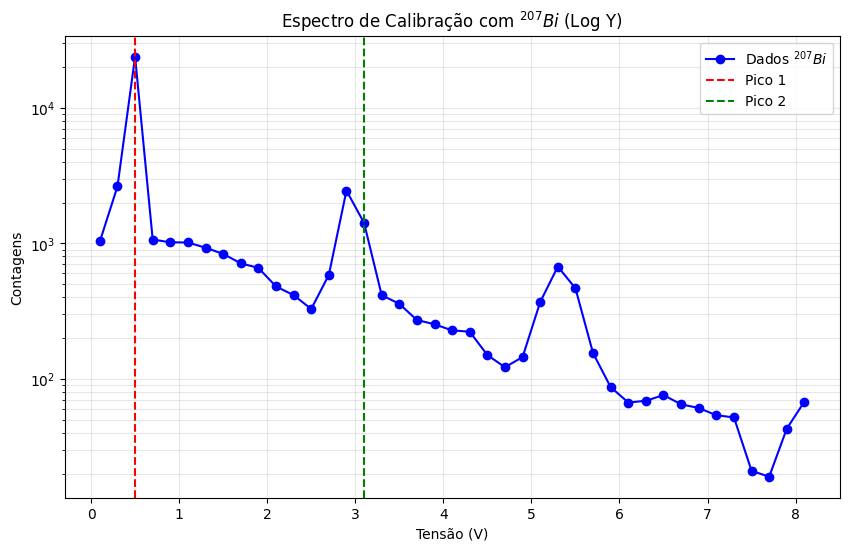

--- RESULTADOS DA CALIBRAÇÃO ---
Equação: E(keV) = (248.19 ± 37.68) * V + (398.05 ± 134.02)
R² (ajuste): 0.9775

FONTE X IDENTIFICADA:
Energia do Fotopico: 1217.06 ± 182.82 keV


In [5]:
import numpy as np
import matplotlib.pyplot as plt
v_bi = np.arange(0.1, 8.2, 0.2)
counts_bi = [1033, 2628, 23789, 1066, 1018, 1015, 928, 836, 712, 659, 481, 415, 328,
             585, 2449, 1415, 415, 358, 272, 253, 228, 223, 150, 122, 145, 369,
             674, 466, 155, 87, 67, 69, 76, 65, 61, 54, 52, 21, 19, 43, 68]
v_obs = np.array([0.5, 3.1, 5.3]); e_teorico = np.array([570, 1063, 1770])
coeffs, cov_matrix = np.polyfit(v_obs, e_teorico, 1, cov=True)
a, b = coeffs; cal_func = np.poly1d(coeffs)
sa = np.sqrt(cov_matrix[0,0]); sb = np.sqrt(cov_matrix[1,1])
v_x_pico1 = 0.3; v_x_pico2 = 3.3
e_x1 = cal_func(v_x_pico1); e_x2 = cal_func(v_x_pico2)
se_x = np.sqrt((v_x_pico2 * sa)**2 + sb**2)
plt.figure(figsize=(10, 6))
plt.semilogy(v_bi, counts_bi, 'b-o', label='Dados ${}^{207}Bi$')
plt.title('Espectro de Calibração com ${}^{207}Bi$ (Log Y)')
plt.xlabel('Tensão (V)'); plt.ylabel('Contagens')
plt.grid(True, which="both", alpha=0.3)
plt.axvline(x=v_obs[0], color='r', linestyle='--', label='Pico 1')
plt.axvline(x=v_obs[1], color='g', linestyle='--', label='Pico 2')
plt.legend(); plt.show()
print(f"--- RESULTADOS DA CALIBRAÇÃO ---")
print(f"Equação: E(keV) = ({a:.2f} ± {sa:.2f}) * V + ({b:.2f} ± {sb:.2f})")
print(f"R² (ajuste): {np.corrcoef(v_obs, e_teorico)[0,1]**2:.4f}")
print(f"\nFONTE X IDENTIFICADA:")
print(f"Energia do Fotopico: {e_x2:.2f} ± {se_x:.2f} keV")